In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)


def basic_statistics_comparison(real_data, generated_data):
    """Сравнение базовой статистики между реальными и сгенерированными данными"""
    print("="*60)
    print("БАЗОВЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ")
    print("="*60)
    
    numeric_cols = ['AMOUNT_EQ', 'PAY_AMT', 'EXCHANGE_RATA', 'HOUR', 'MINUTE', 'SECOND']
    
    for col in numeric_cols:
        if col in real_data.columns and col in generated_data.columns:
            print(f"\n{col}:")
            print("-" * 30)
            print(f"Реальные данные:")
            print(f"  Среднее: {real_data[col].mean():.2f}")
            print(f"  Стандартное отклонение: {real_data[col].std():.2f}")
            print(f"  Минимум: {real_data[col].min():.2f}")
            print(f"  Максимум: {real_data[col].max():.2f}")
            print(f"  Медиана: {real_data[col].median():.2f}")
            print(f"  Количество уникальных: {real_data[col].nunique()}")
            
            print(f"\nСгенерированные данные:")
            print(f"  Среднее: {generated_data[col].mean():.2f}")
            print(f"  Стандартное отклонение: {generated_data[col].std():.2f}")
            print(f"  Минимум: {generated_data[col].min():.2f}")
            print(f"  Максимум: {generated_data[col].max():.2f}")
            print(f"  Медиана: {generated_data[col].median():.2f}")
            print(f"  Количество уникальных: {generated_data[col].nunique()}")


def plot_distribution_comparison(real_data, generated_data):
    """Сравнение распределений числовых переменных"""
    numeric_cols = ['AMOUNT_EQ', 'PAY_AMT', 'HOUR']
    numeric_cols = [col for col in numeric_cols if col in real_data.columns and col in generated_data.columns]
    
    if not numeric_cols:
        return
    
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 5*len(numeric_cols)))
    
    if len(numeric_cols) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(numeric_cols):
        # Гистограмма
        axes[idx, 0].hist(real_data[col], bins=50, alpha=0.5, label='Реальные', density=True)
        axes[idx, 0].hist(generated_data[col], bins=50, alpha=0.5, label='Сгенерированные', density=True)
        axes[idx, 0].set_title(f'Распределение {col}')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Box plot
        data_to_plot = [real_data[col].dropna(), generated_data[col].dropna()]
        axes[idx, 1].boxplot(data_to_plot, labels=['Реальные', 'Сгенерированные'])
        axes[idx, 1].set_title(f'Box plot {col}')
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_categorical_distribution_comparison(real_data, generated_data):
    """Сравнение распределений категориальных переменных"""
    categorical_cols = ['PaymentSystem', 'DETAILEDCARDTYPE', 'IS_OFFLINE', 'IS_ONLINE', 'CITY']
    categorical_cols = [col for col in categorical_cols if col in real_data.columns and col in generated_data.columns]
    
    if not categorical_cols:
        return
    
    n_cols = min(6, len(categorical_cols))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols[:n_cols]):
        # Получаем топ-10 категорий для сравнения
        real_counts = real_data[col].value_counts(normalize=True).head(10)
        gen_counts = generated_data[col].value_counts(normalize=True).head(10)
        
        # Создаем датафрейм для сравнения
        comparison_df = pd.DataFrame({
            'Реальные': real_counts,
            'Сгенерированные': gen_counts
        }).fillna(0)
        
        comparison_df.plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Распределение {col}')
        axes[idx].set_xlabel('Категория')
        axes[idx].set_ylabel('Доля')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    # Скрыть пустые оси
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


def analyze_time_patterns(real_data, generated_data):
    """Анализ временных паттернов"""
    print("="*60)
    print("АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ")
    print("="*60)
    
    if 'HOUR' not in real_data.columns or 'HOUR' not in generated_data.columns:
        return
    
    # Анализ по часам
    real_hour_dist = real_data['HOUR'].value_counts(normalize=True).sort_index()
    gen_hour_dist = generated_data['HOUR'].value_counts(normalize=True).sort_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Распределение по часам
    axes[0].plot(real_hour_dist.index, real_hour_dist.values, 'o-', label='Реальные', linewidth=2)
    axes[0].plot(gen_hour_dist.index, gen_hour_dist.values, 's-', label='Сгенерированные', linewidth=2)
    axes[0].set_title('Распределение транзакций по часам')
    axes[0].set_xlabel('Час')
    axes[0].set_ylabel('Доля транзакций')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Разница в распределениях
    diff_hour = abs(real_hour_dist - gen_hour_dist).mean()
    print(f"Средняя абсолютная разница в распределении по часам: {diff_hour:.4f}")
    
    # Анализ сумм транзакций по часам
    if 'AMOUNT_EQ' in real_data.columns:
        real_hour_avg = real_data.groupby('HOUR')['AMOUNT_EQ'].mean()
        gen_hour_avg = generated_data.groupby('HOUR')['AMOUNT_EQ'].mean()
        
        axes[1].plot(real_hour_avg.index, real_hour_avg.values, 'o-', label='Реальные', linewidth=2)
        axes[1].plot(gen_hour_avg.index, gen_hour_avg.values, 's-', label='Сгенерированные', linewidth=2)
        axes[1].set_title('Средняя сумма транзакций по часам')
        axes[1].set_xlabel('Час')
        axes[1].set_ylabel('Средняя сумма')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def analyze_amount_distribution(real_data, generated_data):
    """Детальный анализ распределения сумм транзакций"""
    if 'AMOUNT_EQ' not in real_data.columns:
        return
    
    print("\n" + "="*60)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ СУММ ТРАНЗАКЦИЙ")
    print("="*60)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Распределение сумм (логарифмированное)
    axes[0, 0].hist(np.log1p(real_data['AMOUNT_EQ']), bins=50, alpha=0.5, label='Реальные', density=True)
    axes[0, 0].hist(np.log1p(generated_data['AMOUNT_EQ']), bins=50, alpha=0.5, label='Сгенерированные', density=True)
    axes[0, 0].set_title('Логарифм сумм транзакций')
    axes[0, 0].legend()
    
    # 2. Эмпирическая функция распределения
    sorted_real = np.sort(real_data['AMOUNT_EQ'])
    sorted_gen = np.sort(generated_data['AMOUNT_EQ'])
    y_real = np.arange(1, len(sorted_real) + 1) / len(sorted_real)
    y_gen = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen)
    
    axes[0, 1].plot(sorted_real, y_real, label='Реальные')
    axes[0, 1].plot(sorted_gen, y_gen, label='Сгенерированные')
    axes[0, 1].set_title('Эмпирическая функция распределения')
    axes[0, 1].set_xlabel('Сумма')
    axes[0, 1].set_ylabel('Вероятность')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. QQ-plot
    stats.probplot(real_data['AMOUNT_EQ'], dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('QQ-plot для реальных данных')
    
    stats.probplot(generated_data['AMOUNT_EQ'], dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-plot для сгенерированных данных')
    
    # 4. Статистики распределения
    real_stats = {
        'Среднее': real_data['AMOUNT_EQ'].mean(),
        'Медиана': real_data['AMOUNT_EQ'].median(),
        'Стд. отклонение': real_data['AMOUNT_EQ'].std(),
        'Асимметрия': real_data['AMOUNT_EQ'].skew(),
        'Эксцесс': real_data['AMOUNT_EQ'].kurtosis()
    }
    
    gen_stats = {
        'Среднее': generated_data['AMOUNT_EQ'].mean(),
        'Медиана': generated_data['AMOUNT_EQ'].median(),
        'Стд. отклонение': generated_data['AMOUNT_EQ'].std(),
        'Асимметрия': generated_data['AMOUNT_EQ'].skew(),
        'Эксцесс': generated_data['AMOUNT_EQ'].kurtosis()
    }
    
    stats_df = pd.DataFrame([real_stats, gen_stats], index=['Реальные', 'Сгенерированные'])
    print("\nСтатистики распределения сумм:")
    print(stats_df.to_string())
    
    # 5. Heatmap для таблицы
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    table = axes[1, 1].table(cellText=stats_df.round(2).values,
                             rowLabels=stats_df.index,
                             colLabels=stats_df.columns,
                             cellLoc='center',
                             loc='center',
                             bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    axes[1, 1].set_title('Сравнение статистик распределения')
    
    # 6. Тест Колмогорова-Смирнова
    ks_statistic, ks_pvalue = stats.ks_2samp(real_data['AMOUNT_EQ'], 
                                            generated_data['AMOUNT_EQ'])
    
    axes[1, 2].text(0.1, 0.5, 
                   f'Тест Колмогорова-Смирнова:\n'
                   f'Статистика: {ks_statistic:.4f}\n'
                   f'p-value: {ks_pvalue:.4f}\n\n'
                   f'Интерпретация:\n'
                   f'{"Распределения одинаковы" if ks_pvalue > 0.05 else "Распределения различны"}',
                   fontsize=12,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    axes[1, 2].set_title('Статистический тест')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()


def analyze_correlations(real_data, generated_data):
    """Анализ корреляций между переменными"""
    print("\n" + "="*60)
    print("АНАЛИЗ КОРРЕЛЯЦИЙ")
    print("="*60)
    
    numeric_cols = ['AMOUNT_EQ', 'EXCHANGE_RATA']
    numeric_cols = [col for col in numeric_cols if col in real_data.columns and col in generated_data.columns]
    
    if len(numeric_cols) < 2:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Матрица корреляций для реальных данных
    real_corr = real_data[numeric_cols].corr()
    sns.heatmap(real_corr, annot=True, fmt='.2f', cmap='coolwarm', 
               square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
    axes[0].set_title('Корреляционная матрица (Реальные данные)')
    
    # Матрица корреляций для сгенерированных данных
    gen_corr = generated_data[numeric_cols].corr()
    sns.heatmap(gen_corr, annot=True, fmt='.2f', cmap='coolwarm', 
               square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
    axes[1].set_title('Корреляционная матрица (Сгенерированные данные)')
    
    plt.tight_layout()
    plt.show()
    
    # Сравнение корреляционных матриц
    corr_diff = (real_corr - gen_corr).abs().mean().mean()
    print(f"Средняя абсолютная разница в корреляциях: {corr_diff:.4f}")


def analyze_transaction_types(real_data, generated_data):
    """Анализ типов транзакций"""
    if 'OpType' not in real_data.columns:
        return
    
    print("\n" + "="*60)
    print("АНАЛИЗ ТИПОВ ТРАНЗАКЦИЙ")
    print("="*60)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Распределение типов операций
    real_optype = real_data['OpType'].value_counts(normalize=True)
    gen_optype = generated_data['OpType'].value_counts(normalize=True)
    
    op_df = pd.DataFrame({'Реальные': real_optype, 'Сгенерированные': gen_optype}).fillna(0)
    op_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Распределение типов операций')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Средняя сумма по типам операций
    if 'AMOUNT_EQ' in real_data.columns:
        real_avg_by_op = real_data.groupby('OpType')['AMOUNT_EQ'].mean()
        gen_avg_by_op = generated_data.groupby('OpType')['AMOUNT_EQ'].mean()
        
        avg_df = pd.DataFrame({'Реальные': real_avg_by_op, 'Сгенерированные': gen_avg_by_op}).fillna(0)
        avg_df.plot(kind='bar', ax=axes[1])
        axes[1].set_title('Средняя сумма по типам операций')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3)
        
    # Количество транзакций на клиента
    if 'ACCOUNT_ID' in real_data.columns:
        real_trans_per_customer = real_data['CustomerKey'].value_counts()
        gen_trans_per_customer = generated_data['CustomerKey'].value_counts()
        
        axes[2].hist(real_trans_per_customer, bins=30, alpha=0.5, label='Реальные', density=True)
        axes[2].hist(gen_trans_per_customer, bins=30, alpha=0.5, label='Сгенерированные', density=True)
        axes[2].set_title('Распределение транзакций на клиента')
        axes[2].set_xlabel('Количество транзакций')
        axes[2].set_ylabel('Плотность')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def calculate_quality_metrics(real_data, generated_data):
    """Расчет метрик качества"""
    print("\n" + "="*60)
    print("МЕТРИКИ КАЧЕСТВА")
    print("="*60)
    
    metrics = {}
    
    # Для числовых колонок
    numeric_cols = ['AMOUNT_EQ', 'PAY_AMT', 'HOUR']
    numeric_cols = [col for col in numeric_cols if col in real_data.columns and col in generated_data.columns]
    
    for col in numeric_cols:
        # Убедимся, что данные совпадают по размеру
        min_len = min(len(real_data[col]), len(generated_data[col]))
        real_vals = real_data[col].iloc[:min_len].values
        gen_vals = generated_data[col].iloc[:min_len].values
        
        # MAE и RMSE
        mae = mean_absolute_error(real_vals, gen_vals)
        rmse = np.sqrt(mean_squared_error(real_vals, gen_vals))
        
        # Wasserstein distance (Earth Mover's Distance)
        wasserstein = stats.wasserstein_distance(real_vals, gen_vals)
        
        metrics[col] = {
            'MAE': mae,
            'RMSE': rmse,
            'Wasserstein': wasserstein
        }
        
    # Для категориальных колонок
    categorical_cols = ['PaymentSystem', 'OpType']
    for col in categorical_cols:
        if col in real_data.columns and col in generated_data.columns:
            # JS дивергенция
            real_dist = real_data[col].value_counts(normalize=True)
            gen_dist = generated_data[col].value_counts(normalize=True)
            
            # Выравниваем распределения
            all_categories = set(real_dist.index) | set(gen_dist.index)
            real_dist_aligned = real_dist.reindex(all_categories).fillna(0)
            gen_dist_aligned = gen_dist.reindex(all_categories).fillna(0)
            
            # JS дивергенция
            m = 0.5 * (real_dist_aligned + gen_dist_aligned)
            js_div = 0.5 * stats.entropy(real_dist_aligned, m) + 0.5 * stats.entropy(gen_dist_aligned, m)
            
            metrics[col] = {'JS_Divergence': js_div}
    
    # Создаем DataFrame с метриками
    metrics_df = pd.DataFrame(metrics).T
    print("\nМетрики качества:")
    print(metrics_df.round(4).to_string())
    
    return metrics_df


def analyze_mcc_distribution(real_data, generated_data):
    """Специфический анализ распределения MCC кодов"""
    if 'MCC' not in real_data.columns:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Топ-20 MCC кодов для реальных данных
    real_mcc_top = real_data['MCC'].value_counts().head(20)
    axes[0].bar(range(len(real_mcc_top)), real_mcc_top.values)
    axes[0].set_xticks(range(len(real_mcc_top)))
    axes[0].set_xticklabels(real_mcc_top.index, rotation=45, ha='right')
    axes[0].set_title('Топ-20 MCC кодов (Реальные данные)')
    axes[0].set_ylabel('Количество')
    axes[0].grid(True, alpha=0.3)
    
    # Топ-20 MCC кодов для сгенерированных данных
    gen_mcc_top = generated_data['MCC'].value_counts().head(20)
    axes[1].bar(range(len(gen_mcc_top)), gen_mcc_top.values)
    axes[1].set_xticks(range(len(gen_mcc_top)))
    axes[1].set_xticklabels(gen_mcc_top.index, rotation=45, ha='right')
    axes[1].set_title('Топ-20 MCC кодов (Сгенерированные данные)')
    axes[1].set_ylabel('Количество')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def analyze_geographical_distribution(real_data, generated_data):
    """Анализ географического распределения транзакций"""
    if 'CITY' not in real_data.columns:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Распределение по городам
    real_city_dist = real_data['CITY'].value_counts(normalize=True).head(10)
    gen_city_dist = generated_data['CITY'].value_counts(normalize=True).head(10)
    
    comparison_df = pd.DataFrame({
        'Реальные': real_city_dist,
        'Сгенерированные': gen_city_dist
    }).fillna(0)
    
    comparison_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Распределение транзакций по городам')
    axes[0].set_xlabel('Город')
    axes[0].set_ylabel('Доля транзакций')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Онлайн/офлайн транзакции
    if 'IS_ONLINE' in real_data.columns and 'IS_OFFLINE' in real_data.columns:
        online_offline_data = pd.DataFrame({
            'Реальные онлайн': [real_data['IS_ONLINE'].mean()],
            'Сгенерированные онлайн': [generated_data['IS_ONLINE'].mean()],
            'Реальные офлайн': [real_data['IS_OFFLINE'].mean()],
            'Сгенерированные офлайн': [generated_data['IS_OFFLINE'].mean()]
        })
        
        online_offline_data.T.plot(kind='bar', ax=axes[1])
        axes[1].set_title('Доля онлайн/офлайн транзакций')
        axes[1].set_ylabel('Доля')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_final_assessment(metrics_df):
    """Вывод итоговой оценки качества"""
    print("\n" + "="*60)
    print("ИТОГОВАЯ ОЦЕНКА КАЧЕСТВА")
    print("="*60)
    
    if 'AMOUNT_EQ' in metrics_df.index:
        mae_amount = metrics_df.loc['AMOUNT_EQ', 'MAE']
        rmse_amount = metrics_df.loc['AMOUNT_EQ', 'RMSE']
        
        if mae_amount < 100 and rmse_amount < 150:
            print("✅ Качество генерации сумм транзакций: ОТЛИЧНО")
        elif mae_amount < 200 and rmse_amount < 300:
            print("⚠️ Качество генерации сумм транзакций: ХОРОШО")
        else:
            print("❌ Качество генерации сумм транзакций: ТРЕБУЕТ ДОРАБОТКИ")
            
    print(f"\nРекомендации:")
    print("1. Обратите внимание на распределение категориальных переменных")
    print("2. Проверьте временные паттерны транзакций")
    print("3. Убедитесь в сохранении корреляционных зависимостей")


def generate_quality_report(real_data, generated_data, save_metrics=True):
    """Генерация полного отчета о качестве данных"""
    
    print("="*80)
    print("ОТЧЕТ О КАЧЕСТВЕ СГЕНЕРИРОВАННЫХ ДАННЫХ")
    print("="*80)
    
    # Общая информация
    print(f"\nОБЩАЯ ИНФОРМАЦИЯ:")
    print(f"  Реальные данные: {len(real_data)} записей, {len(real_data.columns)} колонок")
    print(f"  Сгенерированные данные: {len(generated_data)} записей, {len(generated_data.columns)} колонок")
    
    # Проводим все анализы
    basic_statistics_comparison(real_data, generated_data)
    plot_distribution_comparison(real_data, generated_data)
    plot_categorical_distribution_comparison(real_data, generated_data)
    analyze_time_patterns(real_data, generated_data)
    analyze_amount_distribution(real_data, generated_data)
    analyze_correlations(real_data, generated_data)
    analyze_transaction_types(real_data, generated_data)
    
    # Дополнительные анализы
    analyze_mcc_distribution(real_data, generated_data)
    analyze_geographical_distribution(real_data, generated_data)
    
    # Расчет метрик
    metrics_df = calculate_quality_metrics(real_data, generated_data)
    
    # Итоговая оценка
    print_final_assessment(metrics_df)
    
    # Сохранение метрик
    if save_metrics:
        metrics_df.to_csv('quality_metrics.csv')
        print("\n✅ Метрики сохранены в файл 'quality_metrics.csv'")
    
    return metrics_df


def load_and_prepare_data(real_data_path, generated_data_path=None):
    """Загрузка и подготовка данных для анализа"""
    
    # Загрузка реальных данных
    real_data = pd.read_csv(real_data_path)
    
    # Если сгенерированные данные не предоставлены, создаем тестовые
    if generated_data_path is None:
        print("Создание тестовых сгенерированных данных для демонстрации...")
        np.random.seed(42)
        generated_data = real_data.copy()
        
        # Добавляем небольшой шум для демонстрации
        numeric_cols = ['AMOUNT_EQ', 'PAY_AMT', 'HOUR', 'MINUTE', 'SECOND']
        for col in numeric_cols:
            if col in generated_data.columns:
                noise = np.random.normal(0, generated_data[col].std() * 0.1, len(generated_data))
                generated_data[col] = generated_data[col] + noise
        
        # Случайным образом меняем некоторые категориальные значения
        if 'PaymentSystem' in generated_data.columns:
            mask = np.random.random(len(generated_data)) < 0.1
            generated_data.loc[mask, 'PaymentSystem'] = np.random.choice(
                generated_data['PaymentSystem'].unique(), mask.sum())
        
        if 'OpType' in generated_data.columns:
            mask = np.random.random(len(generated_data)) < 0.05
            generated_data.loc[mask, 'OpType'] = np.random.choice(
                generated_data['OpType'].unique(), mask.sum())
    else:
        # Загрузка сгенерированных данных из файла
        generated_data = pd.read_csv(generated_data_path)
    
    return real_data, generated_data


# Основная функция для запуска анализа


In [5]:
def main():
    """Основная функция для запуска полного анализа"""
    
    print("ЗАГРУЗКА И АНАЛИЗ ДАННЫХ")
    print("="*50)
    
    # Пути к файлам
    real_data_path = 'transact_1.csv'  # Замените на путь к вашим реальным данным
    generated_data_path = None  # Укажите путь к сгенерированным данным, если есть
    
    try:
        # Загрузка данных
        real_data = pd.read_csv('Data/Sber/Clear/transact_1.csv')  # Реальные данные
        generated_data = pd.read_csv('Data/Sber/Clear/transact_400000_samples.csv') 
        # real_data, generated_data = load_and_prepare_data(real_data_path, generated_data_path)
        
        # Генерация полного отчета
        metrics = generate_quality_report(real_data, generated_data)
        
        return metrics
        
    except FileNotFoundError as e:
        print(f"Ошибка: Файл не найден - {e}")
        print("\nПРИМЕР ИСПОЛЬЗОВАНИЯ:")
        print("""
        # Основной способ:
        metrics = generate_quality_report(real_data, generated_data)
        
        # Или по отдельности:
        basic_statistics_comparison(real_data, generated_data)
        plot_distribution_comparison(real_data, generated_data)
        metrics = calculate_quality_metrics(real_data, generated_data)
        
        # Дополнительные анализы:
        analyze_mcc_distribution(real_data, generated_data)
        analyze_geographical_distribution(real_data, generated_data)
        """)
        return None
    except Exception as e:
        print(f"Ошибка: {e}")
        import traceback
        traceback.print_exc()
        return None

ЗАГРУЗКА И АНАЛИЗ ДАННЫХ
ОТЧЕТ О КАЧЕСТВЕ СГЕНЕРИРОВАННЫХ ДАННЫХ

ОБЩАЯ ИНФОРМАЦИЯ:
  Реальные данные: 275259 записей, 36 колонок
  Сгенерированные данные: 400000 записей, 20 колонок
БАЗОВЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ

AMOUNT_EQ:
------------------------------
Реальные данные:
  Среднее: 685.46
  Стандартное отклонение: 729.51
  Минимум: 0.01
  Максимум: 5160.00
  Медиана: 400.00
  Количество уникальных: 56362

Сгенерированные данные:
  Среднее: 708.52
  Стандартное отклонение: 709.46
  Минимум: 161.84
  Максимум: 4731.88
  Медиана: 406.75
  Количество уникальных: 91177

EXCHANGE_RATA:
------------------------------
Реальные данные:
  Среднее: 1.00
  Стандартное отклонение: 0.07
  Минимум: 0.01
  Максимум: 1.00
  Медиана: 1.00
  Количество уникальных: 1260

Сгенерированные данные:
  Среднее: 1.00
  Стандартное отклонение: 0.00
  Минимум: 0.97
  Максимум: 1.00
  Медиана: 1.00
  Количество уникальных: 9100


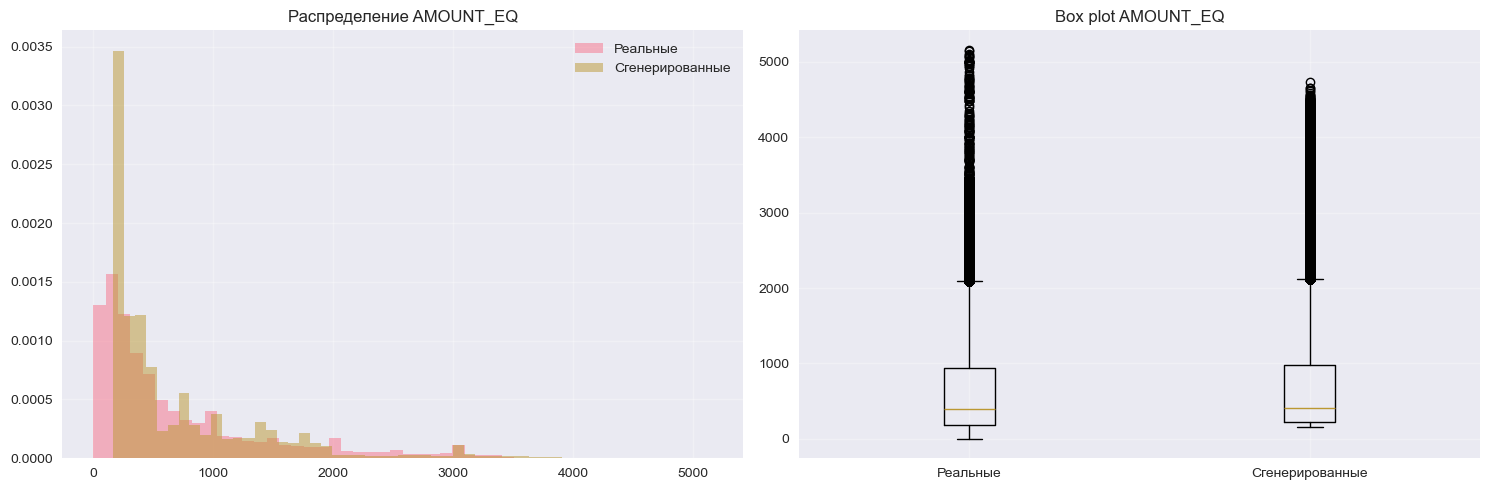

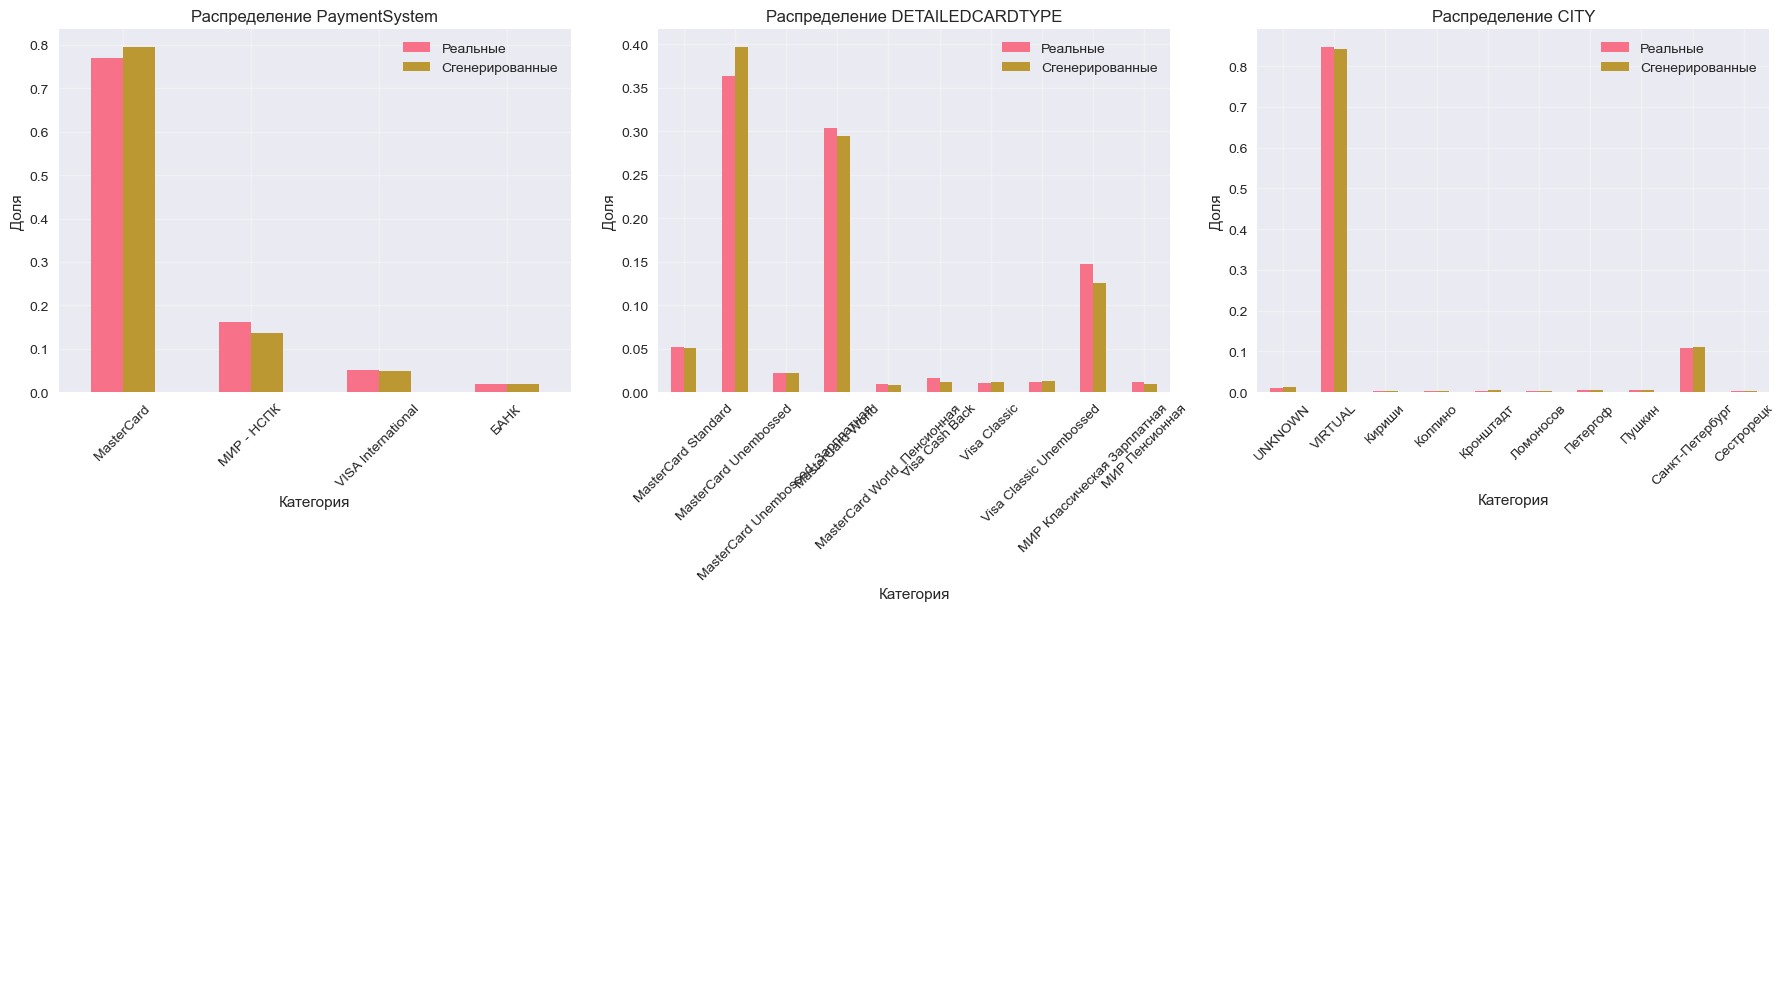

АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ

АНАЛИЗ РАСПРЕДЕЛЕНИЯ СУММ ТРАНЗАКЦИЙ

Статистики распределения сумм:
                    Среднее  Медиана  Стд. отклонение  Асимметрия   Эксцесс
Реальные         685.462818  400.000       729.505995    1.692398  2.470519
Сгенерированные  708.522249  406.745       709.455918    1.971377  4.079798


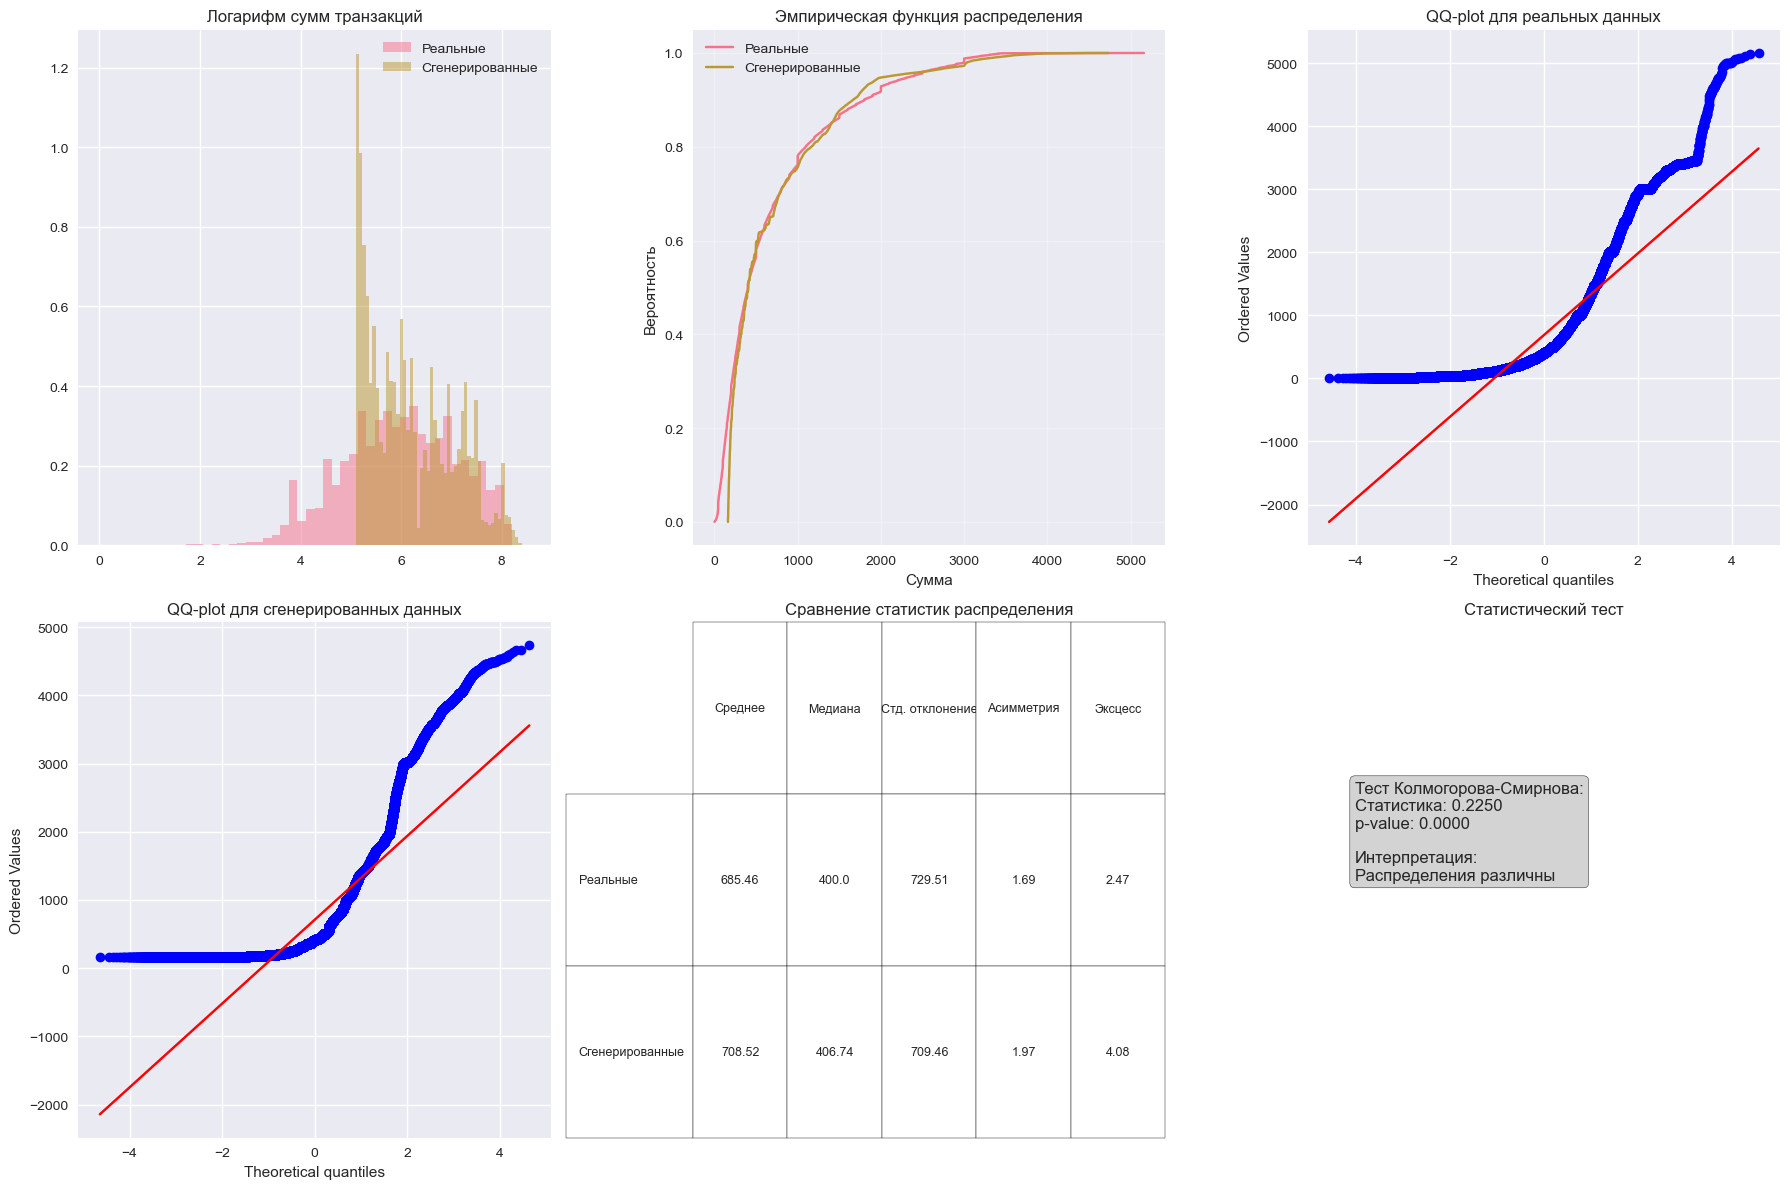


АНАЛИЗ КОРРЕЛЯЦИЙ


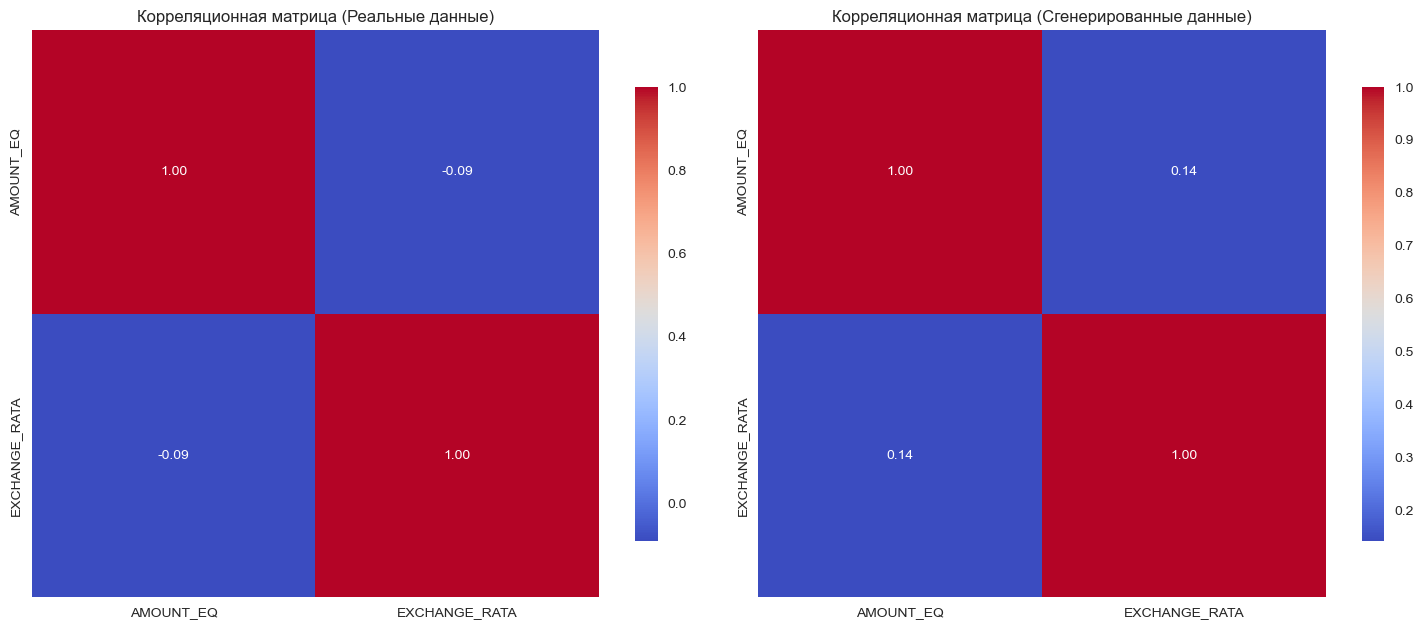

Средняя абсолютная разница в корреляциях: 0.1164

АНАЛИЗ ТИПОВ ТРАНЗАКЦИЙ
Ошибка: 'CustomerKey'


Traceback (most recent call last):
  File "c:\Users\kiril\miniconda3\envs\ml-gpu\lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'CustomerKey'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\kiril\AppData\Local\Temp\ipykernel_4132\536337591.py", line 18, in main
    metrics = generate_quality_report(real_data, generated_data)
  File "C:\Users\kiril\AppData\Local\Temp\ipykernel_4132\1080795696.py", line 508, in generate_quality_report
    analyze_t

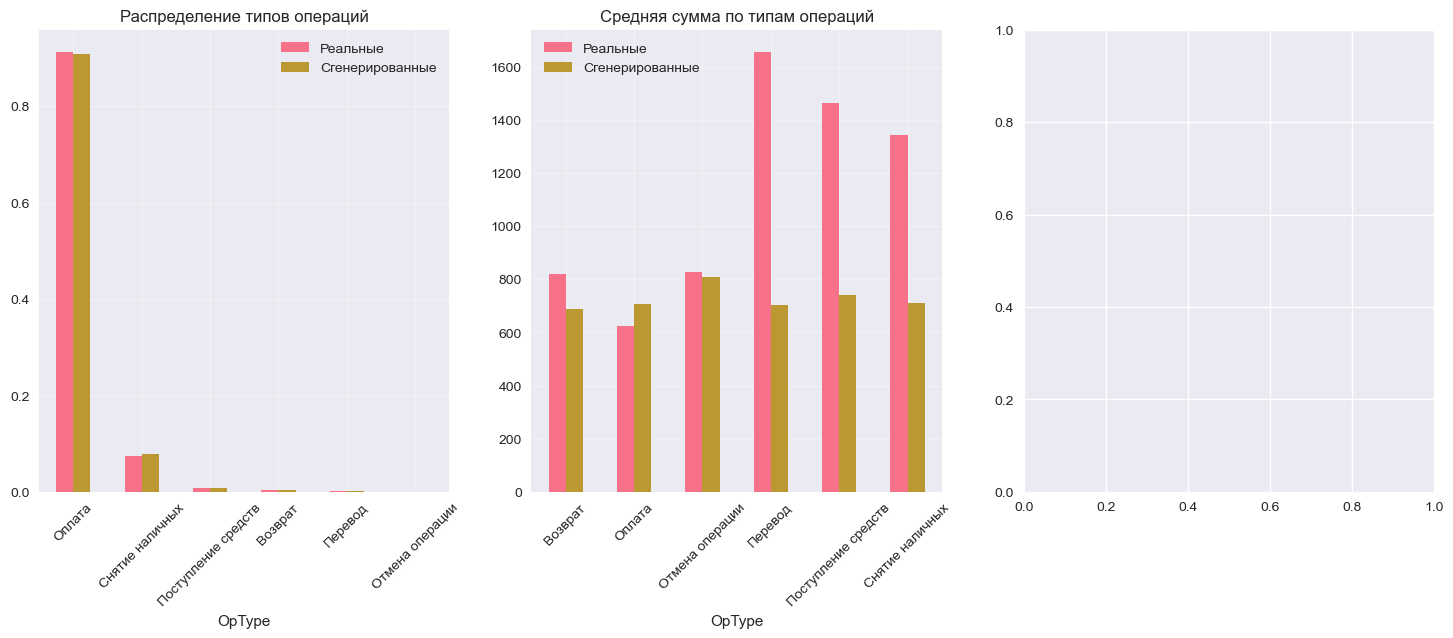

In [6]:
main()